In [1]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
%matplotlib inline

pd.options.mode.chained_assignment = None

In [2]:
class QAOA():
    """
    Implements QAOA for portfolio optimization using a quantum circuit to solve QUBO problems.
    
    Attributes:
        expected_value (list[float]): Expected returns for each asset.
        cov_matrix (DataFrame-like): Covariance matrix between assets.
        q (float): Scaling factor for covariance.
        B (float): Budget/threshold parameter.
        lamb (float): Penalty factor.
        n_assets (int): Number of assets/qubits.
        qc (QuantumCircuit): Initialized circuit in equal superposition.
    """
    
    def __init__(self, expected_value, cov_matrix, q, B, lamb):
        """
        Initializes the QAOA instance and prepares the quantum circuit.
        
        Args:
            expected_value (list[float]): List of asset returns.
            cov_matrix (DataFrame-like): Covariance matrix.
            q (float): Covariance scaling factor.
            B (float): Budget/threshold parameter.
            lamb (float): Penalty parameter.
        """
        
        self.q = q
        self.B = B
        self.lamb = lamb
        self.expected_value = expected_value
        self.cov_matrix = cov_matrix
        self.n_assets = len(expected_value)
        
        self.qc = QuantumCircuit(self.n_assets, self.n_assets)
        # Initialization - prepare an equal superposition state
        for qubit in range(self.n_assets):
            self.qc.h(qubit)
        self.qc.barrier()
        
    
    def cost_hamiltonian_wheight(self, i, j=None):
        """
        Calculate the weights for the Hamiltonian of the QUBO problem.
        
        Args:
            i (int): Index of the first asset.
            j (int, optional): Index of the second asset. Defaults to None.
            
        Returns:
            float: The weight that multiplies the product of the Z operators, acting on qubits i and j.
        """
        
        if j is None:
            response =2*self.expected_value[i]+2*self.lamb*(2*self.B-self.n_assets)-self.q*self.cov_matrix[i].drop([i], axis=0).sum()
        else:
            response = q*self.cov_matrix[i][j]+2*self.lamb
        return response
    
    def draw(self):
        """
        Draws the quantum circuit using matplotlib.
        """
        self.qc.draw(output="mpl", style="iqp")
    
    def add_layer(self, gamma, beta):
        """
        Adds one QAOA layer to the circuit.
        
        This layer applies:
            - Cost Hamiltonian: exp(-i*gamma*H_c) using CNOT and RZ gates.
            - Mixing Hamiltonian: exp(-i*beta*H_B) using RX gates.
        
        Args:
            gamma (float): Parameter for the cost Hamiltonian.
            beta (float): Parameter for the mixing Hamiltonian.
        """
        
        # Implement exp(-i*gamma*H_c)
        # H_c: Cost Hamiltonian
        for i in range(self.n_assets):
            for j in range(i+1, self.n_assets):
                self.qc.cx(i, j)
                self.qc.rz(2*gamma*self.cost_hamiltonian_wheight(i, j), j)
                self.qc.cx(i, j)
        for qubit in range(self.n_assets):
            self.qc.rz(2*gamma*self.cost_hamiltonian_wheight(qubit), qubit)
        self.qc.barrier()
                
        # Implement exp(-i*beta*H_B)
        # H_B = sum(X_i): Mixture Hamiltonian
        for qubit in range(self.n_assets):
             self.qc.rx(2*beta, qubit)
        self.qc.barrier()
             
    def measure_energy(self):
        """
        Measures the circuit and computes the expected energy.
        
        Returns:
            tuple: (energy, counts) where energy is the expected value and counts is the measurement distribution.
    
        """
        
        self.qc.measure(range(self.n_assets), range(self.n_assets))

        simulator = AerSimulator()
        compiled_circuit = transpile(self.qc, simulator)
        sim_result = simulator.run(self.qc).result()
        counts = sim_result.get_counts()
        
        energy = 0
        total_shots = sum(counts.values())
        for bitstring, count in counts.items():
            prob = count / total_shots
            
            Z = [1 if bitstring[::-1][i] == '0' else -1 for i in range(self.n_assets)]
            
            energy_outcome = 0
            for i in range(self.n_assets):
                energy_outcome += self.cost_hamiltonian_wheight(i)*Z[i]
                for j in range(i+1, self.n_assets):
                    energy_outcome += self.cost_hamiltonian_wheight(i, j)*Z[i]*Z[j]
            
            energy += prob * energy_outcome
    
        return energy, counts
        

In [3]:
expected_value = [0.335649, 0.084554, 0.357477, 0.148336]
cov_matrix = pd.DataFrame([
 [0.001077, 0.000257,0.000320,0.000190],
 [0.000257,	0.000441,0.000228,0.000084],
 [0.000320,	0.000228, 0.000867,0.000154],
 [0.000190,	0.000084,0.000154,0.000420]
])

q = 0.5 
B  = 2 
lamb= 1

depth = 20

In [4]:
from scipy.optimize import minimize

In [5]:
def objective(params):
    gamma = params[:depth]
    beta = params[depth:]
    qaoa = QAOA(expected_value, cov_matrix, q, B, lamb)
    for i in range(depth):
        qaoa.add_layer(gamma[i], beta[i])

    energy, _ = qaoa.measure_energy()
    return energy

In [6]:
vec_gamma = []
vec_beta = []
initial_params = []
for _ in range(depth):
    gamma = np.random.uniform(0, 2*np.pi)
    beta = np.random.uniform(0, np.pi)
    vec_gamma.append(gamma)
    vec_beta.append(beta)
    initial_params.append(gamma)
    initial_params.append(beta)
#initial_params = (vec_gamma, vec_beta)

In [7]:
result = minimize(objective, initial_params, method='COBYLA')

In [8]:
result.fun

np.float64(-3.2292840019531246)

In [9]:
result.x
gamma = result.x[:depth]
beta = result.x[depth:]

In [10]:
gamma

array([3.74826138, 1.56393847, 2.56998276, 1.16881448, 0.63353967,
       1.89683586, 1.60548842, 1.26663671, 1.26361271, 2.02923328,
       6.13218378, 0.72026183, 1.4747209 , 0.58989576, 5.27293561,
       0.61976486, 4.08142273, 1.66254601, 3.6950531 , 1.85031283])

In [11]:
beta

array([0.4521018 , 2.16421971, 0.99152734, 0.14094933, 0.48397414,
       2.97352603, 1.72108781, 1.21055578, 4.93788017, 1.56333698,
       0.48130766, 2.27658348, 3.03925317, 2.4032827 , 0.92930591,
       1.11471309, 4.1129831 , 2.05430191, 5.28321869, 1.6018261 ])

In [12]:
qaoa = QAOA(expected_value, cov_matrix, q, B, lamb)
for i in range(depth):
    qaoa.add_layer(gamma[i], beta[i])

In [13]:
energy, counts = qaoa.measure_energy()

In [14]:
energy

np.float64(-3.26538382421875)

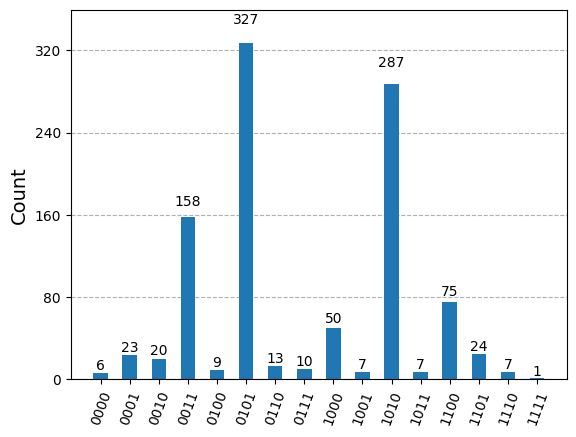

In [15]:
plot_histogram(counts)
plt.show()